<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py0006h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Function Estimation

#### We'll try to estimate the quality of red wine samples based on their physical and chemical features
#### We compute and report the mean absolute error, MAE

In [1]:
# CNN version
# Regression Example With wine dataset ...
import pandas as pd
from pandas import read_csv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# mounting the Google drive
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
fp = "/content/drive/My Drive/Emeritus/Wi20260426/Module3-3/wine_r2_t_noheader.csv"




Mounted at /content/drive


In [3]:

# load dataset to a Pandas dataframe
dataframe = read_csv(fp , header=None)
# copy only values to a numpy n dimensional array, ndarray
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:11]
Y = dataset[:,11]

print(X.shape)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)


(1599, 11)
(1599, 11, 1)


In [4]:
print(type(dataset))
print(dataset.shape)
print(dataframe.describe())
print( dataframe.head() )

<class 'numpy.ndarray'>
(1599, 12)
                0            1            2            3            4   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean      8.319637     0.527821     0.270976     2.538806     0.087467   
std       1.741096     0.179060     0.194801     1.409928     0.047065   
min       4.600000     0.120000     0.000000     0.900000     0.012000   
25%       7.100000     0.390000     0.090000     1.900000     0.070000   
50%       7.900000     0.520000     0.260000     2.200000     0.079000   
75%       9.200000     0.640000     0.420000     2.600000     0.090000   
max      15.900000     1.580000     1.000000    15.500000     0.611000   

                5            6            7            8            9   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean     15.874922    46.467792     0.996747     3.311113     0.658149   
std      10.460157    32.895324     0.001887     0.154386     0.169507   
mi

In [5]:
# define base model, a deep covolutional one
# structure comprisses 2 1d convolution layers with 16 and 12 filters, filters are 3x1
# then maxpooling for downsampling, a fully connected dense layer with 12 neurons
# Droput layer with 20% at the end
#

# //Winston20260426 eveApple2100h.ipynb ;
"""

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, input_dim=8, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""

"""

def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu')) # Removed input_dim
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""



# //Winston20260426 py0006h.ipynb wi gemini solving input dimensions warning by keras ;
"""
def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu')) # Removed input_dim
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
"""




# //Winston20260426 py0006h.ipynb wi gemini solving input dimensions warning by keras ;

"""

Yes, precisely ! The `UserWarning` suggests that instead of including `input_shape` directly in your first layer (like `Conv1D`), you should explicitly define an `Input` layer as the very first layer in your `Sequential` model. This `Input` layer specifies the expected shape of your data entering the model.

Here's how you would typically modify your `baseline_model` function to incorporate this best practice :

"""

from tensorflow.keras.layers import Input

def baseline_model():
    # create model
    model = Sequential()
    # Add an Input layer as the first layer
    model.add(Input(shape=(11, 1))) # Specify the input shape here
    model.add(Conv1D(16, 3, activation="relu")) # Now Conv1D doesn't need input_shape
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

"""

Notice that the `input_shape=(11,1)` is moved to a dedicated `Input` layer at the beginning, and the `Conv1D` layer no longer needs it. This makes the model definition more explicit and aligns with Keras's recommended practices.

&&&&

"""


"\n\nNotice that the `input_shape=(11,1)` is moved to a dedicated `Input` layer at the beginning, and the `Conv1D` layer no longer needs it. This makes the model definition more explicit and aligns with Keras's recommended practices.\n\n&&&&\n\n"

In [6]:
# splitting the train and test subsets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [7]:
# training the model for 900 epochs and testing the trained model with the training data
# we report the training error

# //Winston20260426 eveApple2100h.ipynb ;

estimator = baseline_model()
estimator.fit(X_train, Y_train, epochs=420, verbose=2)

Epoch 1/420
40/40 - 6s - 153ms/step - loss: 27.4327
Epoch 2/420
40/40 - 0s - 3ms/step - loss: 14.0037
Epoch 3/420
40/40 - 0s - 3ms/step - loss: 11.1951
Epoch 4/420
40/40 - 0s - 3ms/step - loss: 8.2798
Epoch 5/420
40/40 - 0s - 7ms/step - loss: 5.1874
Epoch 6/420
40/40 - 0s - 3ms/step - loss: 3.7706
Epoch 7/420
40/40 - 0s - 3ms/step - loss: 3.7682
Epoch 8/420
40/40 - 0s - 3ms/step - loss: 3.7965
Epoch 9/420
40/40 - 0s - 3ms/step - loss: 3.4239
Epoch 10/420
40/40 - 0s - 3ms/step - loss: 3.5683
Epoch 11/420
40/40 - 0s - 4ms/step - loss: 3.4309
Epoch 12/420
40/40 - 0s - 3ms/step - loss: 3.1880
Epoch 13/420
40/40 - 0s - 3ms/step - loss: 3.4395
Epoch 14/420
40/40 - 0s - 3ms/step - loss: 3.2269
Epoch 15/420
40/40 - 0s - 3ms/step - loss: 3.5336
Epoch 16/420
40/40 - 0s - 3ms/step - loss: 3.2393
Epoch 17/420
40/40 - 0s - 3ms/step - loss: 3.4300
Epoch 18/420
40/40 - 0s - 4ms/step - loss: 3.1637
Epoch 19/420
40/40 - 0s - 3ms/step - loss: 3.1935
Epoch 20/420
40/40 - 0s - 3ms/step - loss: 3.2605
Epoc

In [8]:
# //Winston20260426 eveApple2100h.ipynb ;
# splitted this section off so we don't hv to run all the fit epochs again ;

prediction = estimator.predict(X_train)

train_error =  np.abs(Y_train - prediction)
mean_error = np.mean(train_error)
min_error = np.min(train_error)
max_error = np.max(train_error)
std_error = np.std(train_error)
print('\nTraining results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Training results:
mean= 0.7396468068303158 
min= 0.0006499290466308594 
max= 3.802100658416748 
std= 0.5535516179300755


In [9]:
# showing the real and predicted quality scores for the training data
df_train1 = pd.DataFrame({'Actual': Y_train, 'Predicted': prediction.ravel() })
df_train25 = df_train1.tail(25)
print(df_train25)

      Actual  Predicted
1254     6.0   5.449280
1255     6.0   5.068431
1256     5.0   5.170423
1257     5.0   5.495688
1258     6.0   5.268267
1259     5.0   5.347186
1260     5.0   5.363957
1261     5.0   5.506206
1262     6.0   5.752687
1263     6.0   6.146813
1264     5.0   5.098198
1265     5.0   5.593878
1266     5.0   5.113937
1267     4.0   4.793653
1268     5.0   5.314659
1269     6.0   5.263583
1270     6.0   5.731357
1271     6.0   6.294595
1272     6.0   5.572578
1273     5.0   5.111688
1274     5.0   5.311594
1275     5.0   5.092984
1276     6.0   5.462961
1277     6.0   5.908208
1278     5.0   4.738288


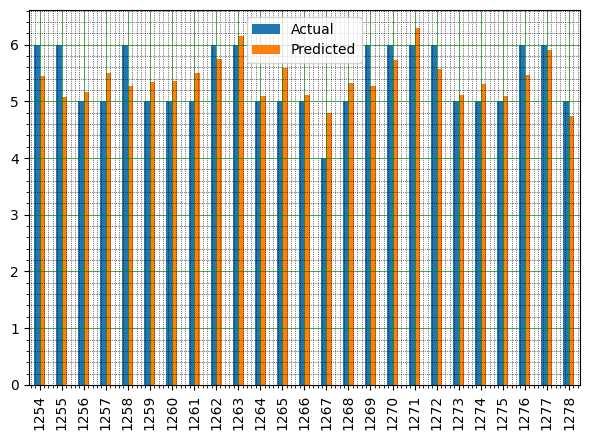

In [10]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_train25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

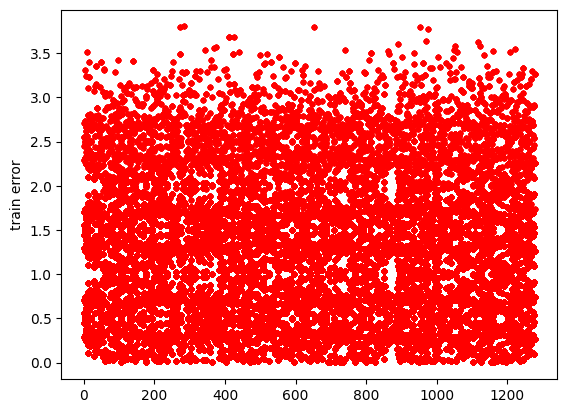

In [11]:
plt.plot(train_error,'r.')
plt.ylabel('train error')
plt.show()

In [12]:
# testing the model with the test data
prediction = estimator.predict(X_test)

test_error =  np.abs(Y_test - prediction)
mean_error = np.mean(test_error)
min_error = np.min(test_error)
max_error = np.max(test_error)
std_error = np.std(test_error)
print('\nTesting results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Testing results:
mean= 0.6904433619976044 
min= 0.0007681846618652344 
max= 3.802100658416748 
std= 0.5198056928460169


In [13]:
# and showing the results
df_test1 = pd.DataFrame({'Actual': Y_test, 'Predicted': prediction.ravel() })
df_test25 = df_test1.tail(25)
print(df_test25)

     Actual  Predicted
295     6.0   5.636535
296     6.0   5.427338
297     5.0   5.590233
298     6.0   5.319633
299     5.0   5.314504
300     6.0   5.479665
301     5.0   4.705686
302     6.0   5.499279
303     6.0   5.743111
304     6.0   5.671684
305     6.0   5.847325
306     5.0   4.868899
307     5.0   4.913573
308     6.0   5.694118
309     5.0   5.444680
310     5.0   5.416832
311     6.0   5.908969
312     5.0   5.563747
313     5.0   5.235547
314     5.0   5.093612
315     6.0   5.589018
316     4.0   5.856998
317     5.0   5.623906
318     4.0   4.821717
319     6.0   5.689996


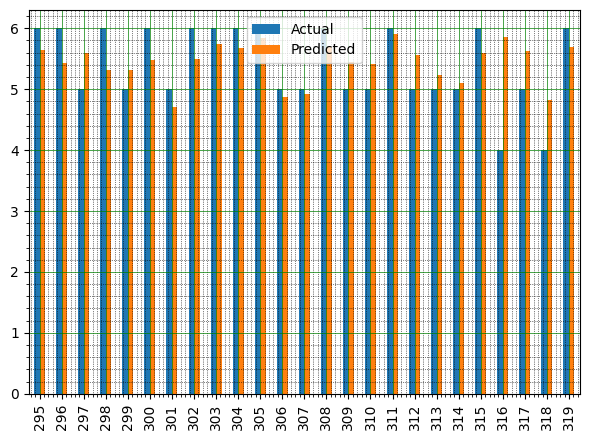

In [14]:
# df1.plot(kind='bar',figsize=(10,8))
# plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# plt.show()

# //Winston20260426 eveApple2100h.ipynb ;
# cannot see Colab.Gemini code edits in Chrome on Apple ;
df_test25.plot(kind='bar',figsize=(6,4.5))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
# //Winston20260426 eveApple2100h.ipynb ;
plt.tight_layout()
plt.show()

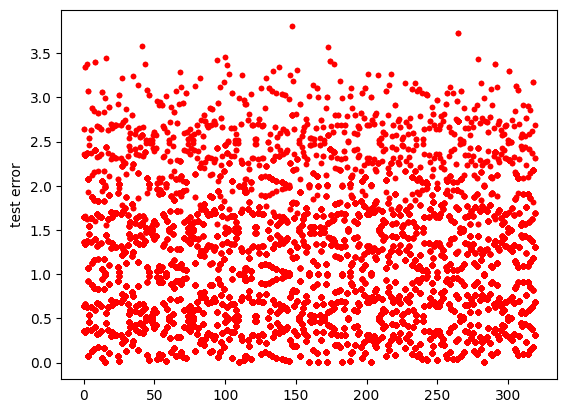

In [15]:
plt.plot(test_error,'r.')
plt.ylabel('test error')
plt.show()

##  Practices
1. train the model for 1400 epochs. what are the training and testing MAE?
2. repeat that with 6000 training epochs. what are the training and testing MAE?
3. move back to 900 training epochs. add two convolutional and one dense layer with the same features of the layers used. what are the training and testing MAE?
4. go for 6000 training epochs. Do you feel any overfitting?
5. set back everything to the original setting, then try to normalize the training and testing features and outputs using standard_scaler. Then see if anything gets better or not. You may use insttructions like what you can see in the next cell.  

#### points:
- use GPU as your runtime type
- if the notebook overflows, change the verbose to 0, e.g. verbose=0 in the training cell.

In [16]:
'''
# normalization
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize X_train and X_test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)
y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed
y_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))
'''

'\n# normalization\nfrom sklearn.preprocessing import StandardScaler\n\n# Create scalers\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\n\n# Standardize X_train and X_test\nX_train_scaled = scaler_X.fit_transform(X_train)\nX_test_scaled = scaler_X.transform(X_test)\n\n# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)\ny_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed\ny_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))\n'